### *Preprocessing,Model Build and Evaluation*

In [4]:
#Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix,RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')


In [5]:
#load raw dataset
df=pd.read_csv("D:\Resume Project\churn predction\data\Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
#drop unnecessary column
df.drop('customerID',axis=1,inplace=True)


In [7]:
#encode target column
label_encoder=LabelEncoder()
df['Churn']=label_encoder.fit_transform(df.Churn)

In [8]:
df.duplicated().sum()

np.int64(22)

In [9]:
#droo duplicated value
df.drop_duplicates(inplace=True)

In [12]:
#Totalcharges column convert str to int
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df.dropna(inplace=True)

In [13]:
#separate independent and target column
x=df.drop('Churn',axis=1)
y=df['Churn']

In [14]:
#train test split 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)

In [15]:
#shape of train and test data
print(x_train.shape)
print(x_test.shape)

(5608, 19)
(1402, 19)


In [16]:
# find categorical and numerical columns
categorical_col=x_train.select_dtypes(include=['object']).columns
numerical_col=x_train.select_dtypes(include=['int64','float64']).columns
print(f"categorical columns are: {categorical_col}\n")
print(f"numerical columns are: {numerical_col}")

categorical columns are: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

numerical columns are: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


In [17]:
# Column Transformer
preprocessor=ColumnTransformer(
    transformers=[('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False),categorical_col),
                  ('scaling',StandardScaler(),numerical_col)]
)

In [29]:
# create complete pipeline
model_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(n_estimators=50,max_features='sqrt',random_state=40))
])

# train the model 
model_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoder', ...), ('scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

##### Model Evaluation

In [30]:
# find accuracy, precision, recall,f1 score
y_pred=model_pipeline.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print(f'Accuracy: {accuracy}\n')
print(f'precision: {precision}\n')
print(f'Recall : {recall}\n')
print(f'F1 score: {f1}')

Accuracy: 0.8124108416547788

precision: 0.6677740863787376

Recall : 0.5521978021978022

F1 score: 0.6045112781954888


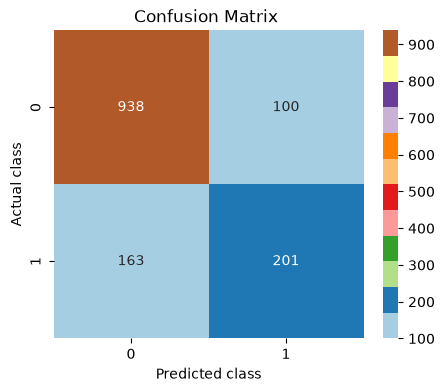

In [31]:
# Plot confusion matrix
confusion=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(confusion,annot=True,fmt='d',cmap='Paired')
plt.title('Confusion Matrix ')
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.show()

<Figure size 500x500 with 0 Axes>

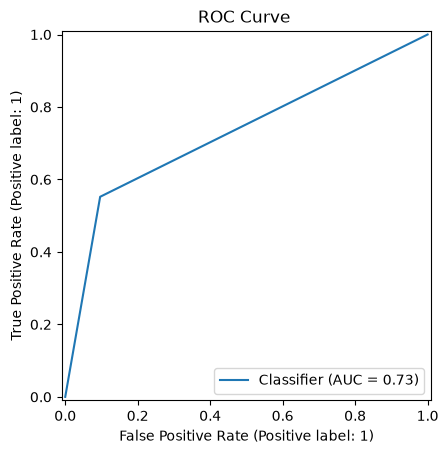

In [32]:
# plot ROC AUC curve
plt.figure(figsize=(5,5))
RocCurveDisplay.from_predictions(y_test,y_pred)
plt.title('ROC Curve ')

plt.show()

#### save model

In [35]:
#save the model 
with open('../models/model.pkl','wb')as f:
    pickle.dump(model_pipeline,f)
print('model saved successfully')

model saved successfully
